# Simplified Two-Level MOT Validation

This notebook uses the isolated `pmot.mot_simple` package to validate a deterministic two-level MOT model before returning to the multilevel simulation.

In [1]:
%matplotlib widget

import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from pmot.state import AtomState
from pmot.magnetic_fields import default_anti_helmholtz_config
from pmot.mot_simple import (
    build_simple_mot_beams,
    default_simple_mot_config,
    mean_force_n,
    plot_magnetic_component_grid,
    plot_simple_mot_diagnostics,
    plot_simple_mot_geometry,
    rate_samples,
    simple_mot_paths,
    simulate_simple_mot_trajectory,
)

PATHS = simple_mot_paths()
CONFIG = default_simple_mot_config()
COIL_CONFIG = default_anti_helmholtz_config()
BEAMS = build_simple_mot_beams(simple_config=CONFIG)

for output_path in (
    PATHS['outputs_fields_simple_mot'],
    PATHS['outputs_trajectories_simple_mot'],
    PATHS['outputs_figures_simple_mot'],
):
    output_path.mkdir(parents=True, exist_ok=True)


,parameter,value
0,cooling detuning [MHz],-15.0
1,linewidth [MHz],6.065
2,effective mu/h [MHz/G],1.399625
3,gravity enabled,True
4,xi(horizontal_x),1.0
5,xi(horizontal_y),1.0
6,xi(vertical_z),-1.0


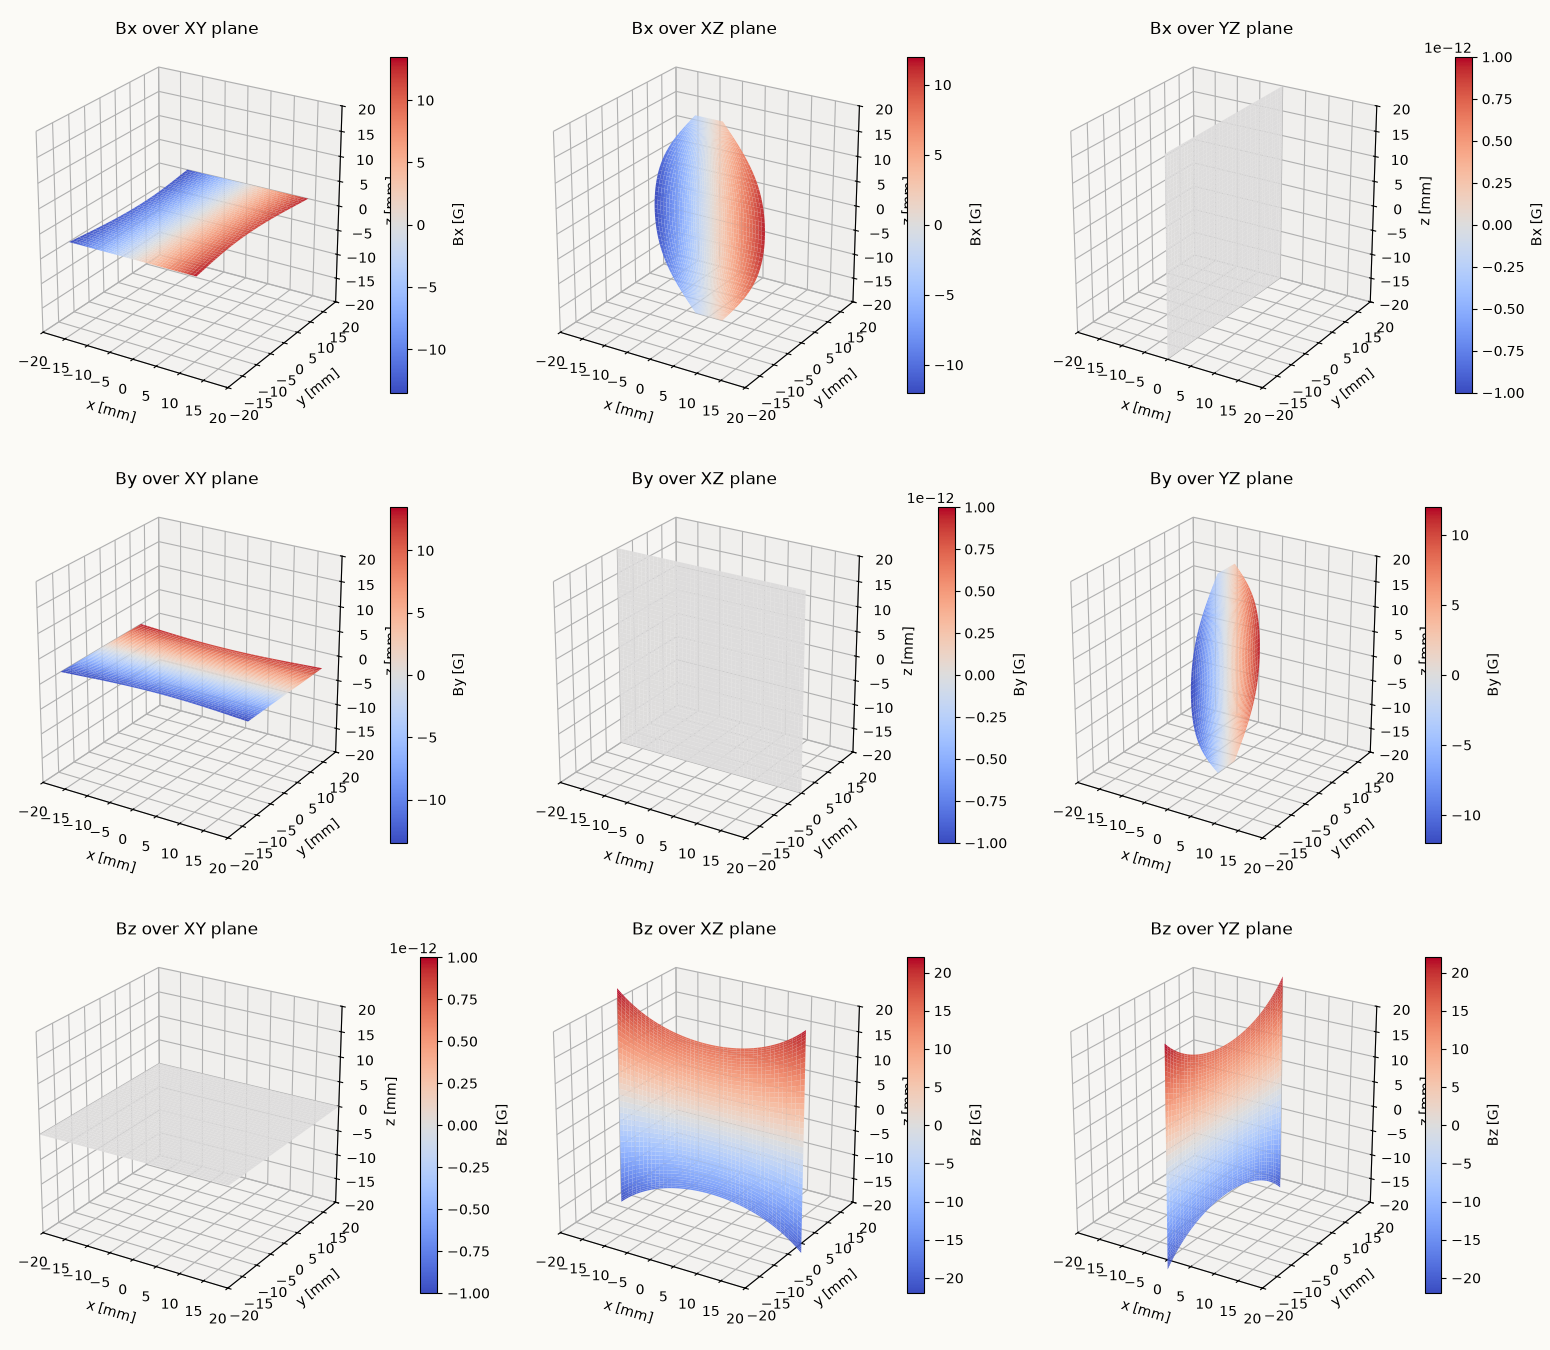

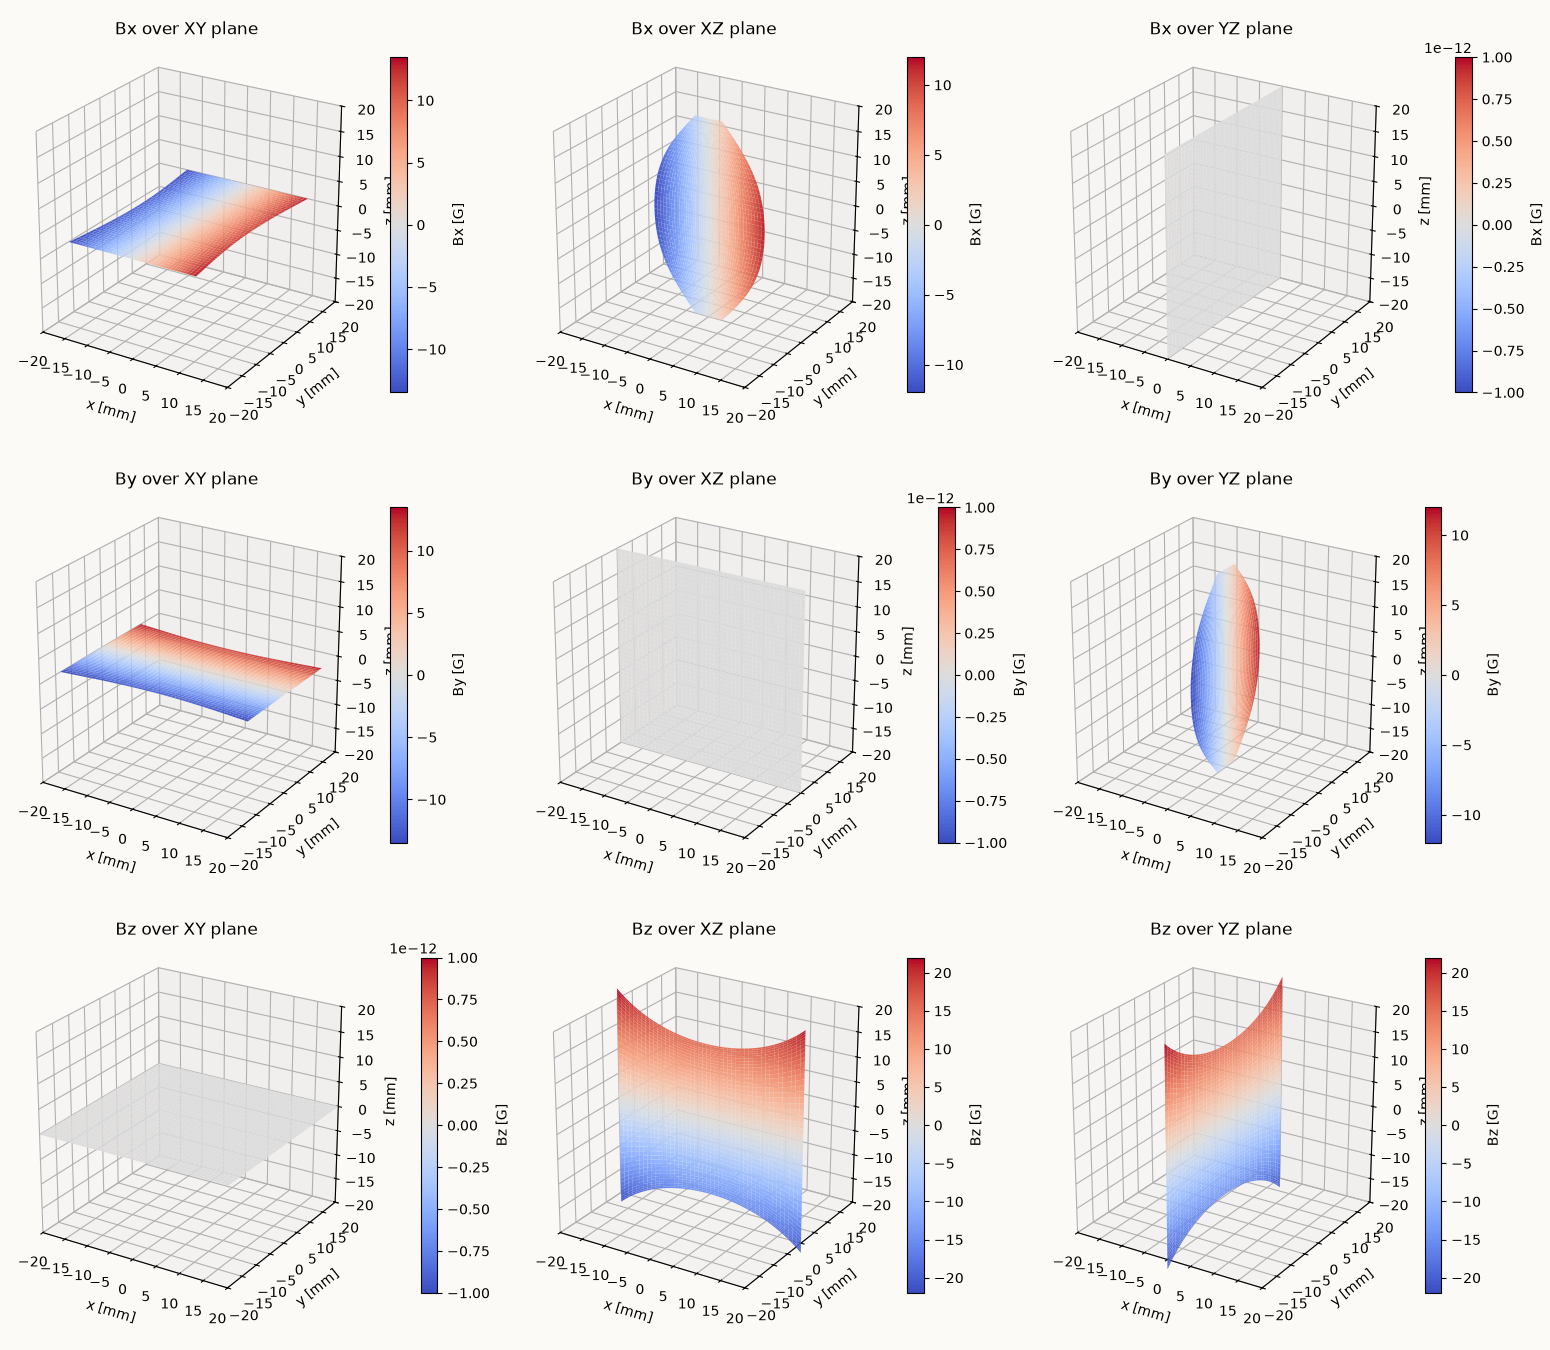

In [ ]:
plt.close("all")

summary = pd.DataFrame(
    {
        'parameter': [
            'cooling detuning [MHz]',
            'linewidth [MHz]',
            'effective mu/h [MHz/G]',
            'gravity enabled',
            'xi(horizontal_x)',
            'xi(horizontal_y)',
            'xi(vertical_z)',
        ],
        'value': [
            CONFIG.cooling_detuning_hz / 1e6,
            CONFIG.linewidth_hz / 1e6,
            CONFIG.effective_magnetic_moment_hz_per_t / 1e10,
            CONFIG.include_gravity,
            CONFIG.axis_polarization_sign['horizontal_x'],
            CONFIG.axis_polarization_sign['horizontal_y'],
            CONFIG.axis_polarization_sign['vertical_z'],
        ],
    }
)
display(summary)

plot_magnetic_component_grid(
    coil_config=COIL_CONFIG,
    extent_m=CONFIG.plot_extent_m,
    samples_per_axis=CONFIG.sample_count_per_axis,
    path=PATHS['outputs_fields_simple_mot'] / 'simple_mot_magnetic_components.png',
)
plt.show()

# plot_simple_mot_geometry(
#     beams=BEAMS,
#     initial_position_m=(0.0, 0.0, 10.0e-3),
#     path=PATHS['outputs_figures_simple_mot'] / 'simple_mot_geometry.png',
# )
#plt.show()


In [5]:
x0_widget = widgets.FloatSlider(value=0.0, min=-20.0, max=20.0, step=0.5, description='x0 [mm]')
y0_widget = widgets.FloatSlider(value=0.0, min=-20.0, max=20.0, step=0.5, description='y0 [mm]')
z0_widget = widgets.FloatSlider(value=10.0, min=-20.0, max=20.0, step=0.5, description='z0 [mm]')
vx0_widget = widgets.FloatSlider(value=0.0, min=-10.0, max=10.0, step=0.01, description='vx0')
vy0_widget = widgets.FloatSlider(value=0.0, min=-10.0, max=10.0, step=0.01, description='vy0')
vz0_widget = widgets.FloatSlider(value=-1.0, min=-10.0, max=10.0, step=0.01, description='vz0')
detuning_widget = widgets.FloatSlider(value=-15.0, min=-30.0, max=5.0, step=0.5, description='det [MHz]')
duration_widget = widgets.FloatSlider(value=10.0, min=0.1, max=30.0, step=0.1, description='T [ms]')
dt_widget = widgets.FloatLogSlider(value=2.0, base=10, min=-7, max=-4, step=0.05, description='dt [s]')
recompute_button = widgets.Button(description='Recompute', button_style='primary')
output = widgets.Output()

def run_simple_mot(_button):
    with output:
        output.clear_output(wait=True)
        config = default_simple_mot_config()
        config = type(config)(
            cooling_detuning_hz=detuning_widget.value * 1e6,
            linewidth_hz=config.linewidth_hz,
            saturation_intensity_w_per_m2=config.saturation_intensity_w_per_m2,
            effective_magnetic_moment_hz_per_t=config.effective_magnetic_moment_hz_per_t,
            axis_polarization_sign=config.axis_polarization_sign,
            include_gravity=config.include_gravity,
            gravity_acceleration_m_per_s2=config.gravity_acceleration_m_per_s2,
            sample_count_per_axis=config.sample_count_per_axis,
            plot_extent_m=config.plot_extent_m,
        )
        beams = build_simple_mot_beams(simple_config=config)
        initial_state = AtomState(
            position_m=(1e-3 * x0_widget.value, 1e-3 * y0_widget.value, 1e-3 * z0_widget.value),
            velocity_m_per_s=(vx0_widget.value, vy0_widget.value, vz0_widget.value),
        )
        force, samples, magnetic_field = mean_force_n(beams, initial_state, COIL_CONFIG, config)
        display(pd.DataFrame(
            {
                'beam_label': [sample.beam_label for sample in samples],
                'detuning_mhz': [sample.effective_detuning_hz / 1e6 for sample in samples],
                'rate_per_s': [sample.scattering_rate_per_s for sample in samples],
            }
        ).sort_values('rate_per_s', ascending=False))
        print('B-field [T]:', magnetic_field)
        print('Mean force [N]:', force)
        record = simulate_simple_mot_trajectory(
            beams=beams,
            initial_state=initial_state,
            duration_s=1e-3 * duration_widget.value,
            time_step_s=dt_widget.value,
            coil_config=COIL_CONFIG,
            simple_config=config,
        )
        plot_simple_mot_diagnostics(
            record,
            path=PATHS['outputs_trajectories_simple_mot'] / 'simple_mot_diagnostics.png',
        )
        plt.show()

recompute_button.on_click(run_simple_mot)
display(
    widgets.VBox([
        widgets.HBox([x0_widget, y0_widget, z0_widget]),
        widgets.HBox([vx0_widget, vy0_widget, vz0_widget]),
        widgets.HBox([detuning_widget, duration_widget, dt_widget]),
        recompute_button,
        output,
    ])
)
